# Computing the Hessian matrix


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cvxpy as cp

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.core import compute_expression_shift_by_mutation
from promdis.core import compute_expression_shift_by_pairwise_mutation
from promdis.pl import plot_data, plot_data_2d

In [4]:
OUTDIR = "../results/hessians"

os.makedirs(OUTDIR, exist_ok=True)

In [5]:
FPATH = "../data/expression_data/ykgE_dataset_combined.csv"

In [6]:
df = pd.read_csv(FPATH)
df['barcode'] = df['seq'].str.slice(160,)
df['promoter'] = df['seq'].str.slice(0, 160)
df

,ct,ct_0,ct_1,seq,barcode,promoter
0,1.0,1.0,0.0,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...,GAGAGCCTCGCGTATCCCTC,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...
1,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,GGATCCATGGTCATTCGGTG,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
2,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,TATTACGGTACGAGATTGCT,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
3,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,AACTCTCACTCTGCTGTACG,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
4,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,TACCCGTGTTCGTAACCCCT,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
...,...,...,...,...,...,...
2585,1.0,1.0,0.0,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...,CGCATACGGTAGAAGCGGAA,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...
2586,2.0,1.0,1.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CGTCCTTTACGTACTATGGG,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2587,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CACGTCAGCGGCCCTCTTAC,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2588,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,GTATCCGTGCGACCATCCAA,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...


In [7]:
seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
    df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
)

expression = counts_rna / (counts_dna + counts_rna)

In [8]:
# Load wildtype data

GENE = 'ykgE'

WT_GENES_FPATH = "../data/wtsequences.csv"

wildtype_genes_df = pd.read_csv(WT_GENES_FPATH)

WT_GENE_SEQUENCES = {
    g: wildtype_genes_df.loc[wildtype_genes_df['name'] == g,'geneseq'].values[0]
    for g in wildtype_genes_df['name'].unique()
}

GENE_WT_SEQ = WT_GENE_SEQUENCES[GENE]

nbases = len(GENE_WT_SEQ)
print(f"{GENE} wildtype sequence (length {nbases}):\n", GENE_WT_SEQ)

wt_seq = gene_seq_to_array(GENE_WT_SEQ)

ykgE wildtype sequence (length 160):
 TCGATTTCCCCATAAAATGTGAGCGATGCCGAAAGAAATAAAATTAGTTATTGCATTTGACGTTTGGATGAAAGATTATCATTTGTCATACAAATGAGGGGTGGTATGTTGCTAGCCAATTAAAAAAGAACGCCATATTTATTGATGATTGATCCCCCGG


Compute the expression shift for individual segments.
This gives us points along each segment axis.

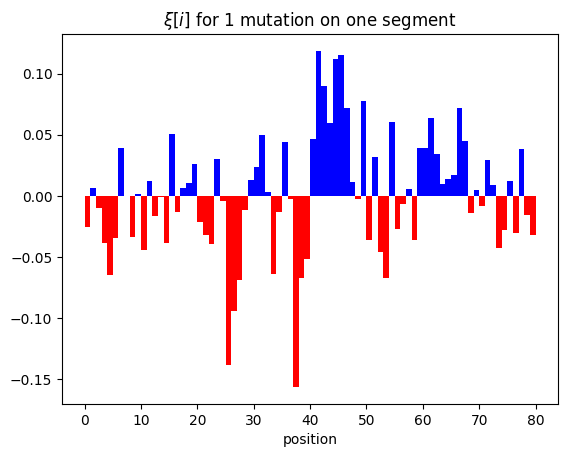

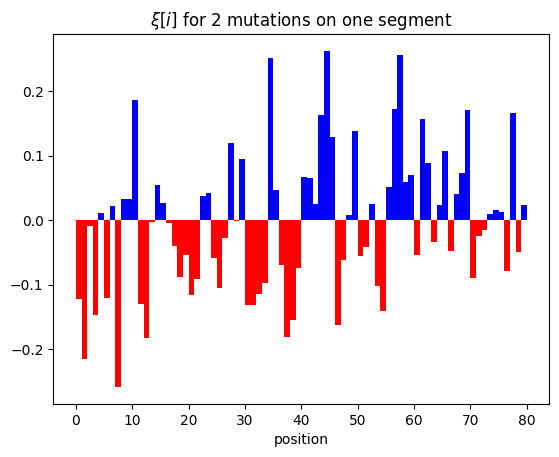

In [9]:
# Collect data for single segment mutations

profile_groups = [
    [(0,1), (1,0)],  # 1 mutation on the segment
    [(1,1)],         # 2 mutations on the segment
]
xis, _ = compute_expression_shift_by_mutation(
    seqs, expression, wt_seq, 2,
    profile_groups=profile_groups
)
xi_single_1mut = xis[0]
xi_single_2mut = xis[1]

# Plot single mutation
ax = plot_data(xi_single_1mut)
ax.set_title("$\\xi[i]$ for 1 mutation on one segment")

# Plot double mutation
ax = plot_data(xi_single_2mut)
ax.set_title("$\\xi[i]$ for 2 mutations on one segment");


Compute the expression shift for mutations to pairwise segments.

/Users/joelandsittel/Documents/Promote Dissection/promotor-dissection/promdis/core.py:417: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


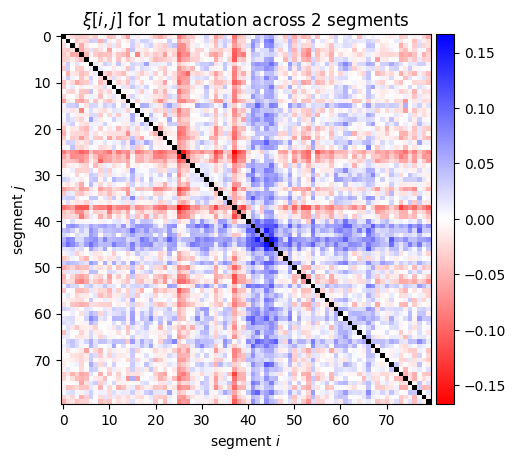

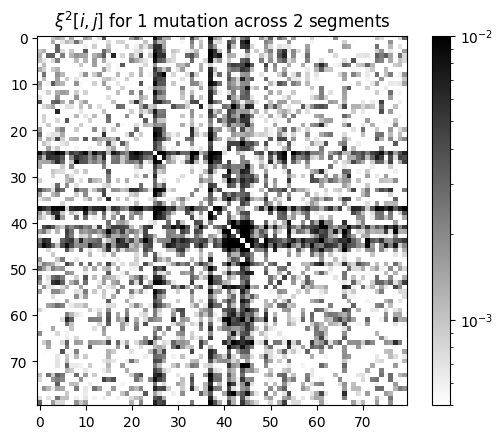

In [10]:
# Collect data for pairwise segments

# All instances with a single mutation across the 2 segments.
profile_groups = [
    [((0,0),(0,1)), ((0,0),(1,0)), ((0,1),(0,0)), ((1,0),(0,0))]
]
xis, _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq, 2,
    profile_groups=profile_groups
)
xi_double_1mut = xis[0]

# Plot data
ax = plot_data_2d(xi_double_1mut)
ax.set_title("$\\xi[i,j]$ for 1 mutation across 2 segments")

# Plot squared data
fig, ax = plt.subplots()
cax = ax.imshow(xi_double_1mut**2, cmap='binary', norm=LogNorm(vmin=0.0005, vmax=0.01))
cbar = fig.colorbar(cax)
ax.set_title("$\\xi^2[i,j]$ for 1 mutation across 2 segments")

plt.show()


In [11]:
# Collect Fit Data 

gamma_single_1mut = xi_single_1mut**2
gamma_single_2mut = xi_single_2mut**2
gamma_double_1mut = xi_double_1mut**2

N = len(gamma_single_1mut)
data_to_fit = np.zeros((int(N*(N - 1)/2 + 2*N + 1), N + 1)) 

#N*(N - 1)/2: Number of "pairwise" points
#2N: Number of points along an axis.
#1: The origin

for i in range(1, N + 1):
    data_to_fit[i][i - 1] = 0.5
    data_to_fit[i][N] = gamma_single_1mut[i - 1]
for i in range(N + 1, 2*N + 1):
    data_to_fit[i][i - N - 1] = 1
    data_to_fit[i][N] = gamma_single_2mut[i - N - 1]
row = 2*N + 1
for i in range(1, 80):
    for j in range(0, i):
        data_to_fit[row][i] = 0.5
        data_to_fit[row][j] = 0.5
        data_to_fit[row][N] = gamma_double_1mut[i][j]
        row += 1

print("Shape of data matrix:", np.shape(data_to_fit))
np.savetxt('matrix.txt', data_to_fit)

Shape of data matrix: (3321, 81)


We now fit an $N$-dimensional elliptic paraboloid to the data.

In [12]:
X = data_to_fit[:, :-1]  # First 80 columns
y = data_to_fit[:, -1]   # Last column

n = X.shape[1]  # number of segments

# Coefficients to fit constitute a symmetric positive definite matrix Q.
# We first instantiate a symmetric n x n matrix, then enforce positivity.
# See https://www.cvxpy.org/examples/basic/sdp.html?h=definite#scalar-functions
Q = cp.Variable((n, n), symmetric=True)
constraints = [Q >> 0] 

# Predicted values are yhat = x^T Q x
pred = cp.sum(cp.multiply(X @ Q, X), axis=1)

# Least squares objective
objective = cp.Minimize(cp.sum_squares(pred - y))

problem = cp.Problem(objective, constraints)
problem.solve()
Q = Q.value

print(f"Coefficients of the fitted {n}-dimensional paraboloid:")
print(Q)

Coefficients of the fitted 80-dimensional paraboloid:
[[ 2.52833833e-03 -1.31626668e-03  3.94585521e-04 ... -1.30109773e-03
   6.87776887e-04  9.92485559e-04]
 [-1.31626668e-03  8.46537997e-03 -7.17114098e-04 ... -5.65384661e-04
  -8.67296912e-04 -8.37547490e-04]
 [ 3.94585521e-04 -7.17114098e-04  4.18201463e-04 ...  6.04275609e-05
   3.41775328e-04  5.15507133e-04]
 ...
 [-1.30109773e-03 -5.65384661e-04  6.04275609e-05 ...  5.03756457e-03
  -1.51961388e-04 -1.01554609e-03]
 [ 6.87776887e-04 -8.67296912e-04  3.41775328e-04 ... -1.51961388e-04
   4.71724448e-04  5.85369645e-04]
 [ 9.92485559e-04 -8.37547490e-04  5.15507133e-04 ... -1.01554609e-03
   5.85369645e-04  1.17319024e-03]]


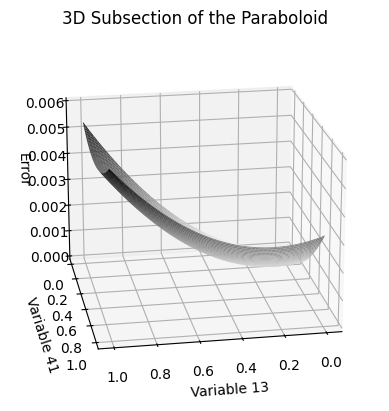

In [13]:
def plot_parabaloid(Q, var1_index, var2_index):
    
    var1_range = np.linspace(0, 1, 100)  
    var2_range = np.linspace(0, 1, 100)  
    var1_grid, var2_grid = np.meshgrid(var1_range, var2_range)

    grid_points = np.zeros((var1_grid.size, 80))
    grid_points[:, var1_index] = var1_grid.ravel()
    grid_points[:, var2_index] = var2_grid.ravel()
    val = np.einsum('ij,ij->i', grid_points @ Q, grid_points)
    z_grid = val.reshape(var1_grid.shape)

    # Plot the 3D subsection
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(var1_grid, var2_grid, z_grid, cmap='binary')
    z_ticks = np.linspace(np.min(z_grid), np.max(z_grid), num=5)
    ax.set_xlabel(f'Variable {var1_index + 1}')
    ax.set_ylabel(f'Variable {var2_index + 1}')
    ax.set_zlabel('Error')
    ax.set_title('3D Subsection of the Paraboloid')
    
    ax.view_init(elev=20., azim=80)

    plt.show()


plot_parabaloid(Q, 12, 40)  # Plot using the first two independent variables


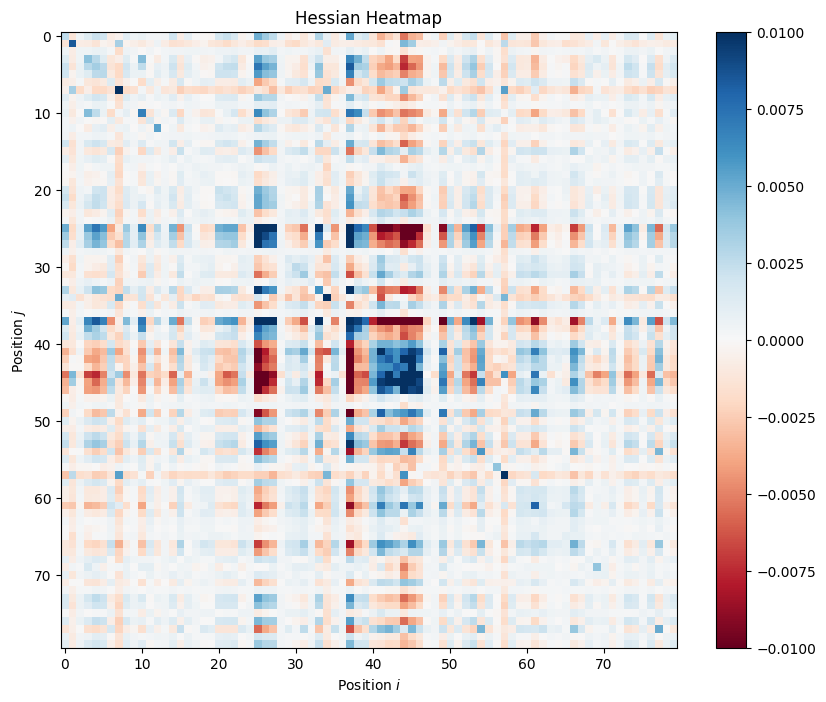

In [14]:
# Extract the coefficients of the fitted model
# coefficients = beta.value

# Initialize the Hessian matrix with zeros
# hessian = np.zeros((N, N))
# hessian = Q.value

# Fill the Hessian matrix with the appropriate coefficients
# index = 1  
# for i in range(N):
#     for j in range(i, N):
#         hessian[i, j] = coefficients[index]
#         hessian[j, i] = coefficients[index]
#         index += 1

# print(hessian)

plt.figure(figsize=(10, 8))
plt.imshow(Q, cmap='RdBu', interpolation='nearest', vmin = -0.01, vmax = 0.01)
plt.colorbar()
plt.title('Hessian Heatmap')
plt.xlabel('Position $i$')
plt.ylabel('Position $j$')
plt.show()


Eigenvalues:
 [ 1.78804970e-01  5.61912546e-02  2.33443620e-02  1.78041247e-02
  1.55509258e-02  1.12830420e-02  9.80428696e-03  7.54814942e-03
  5.66702079e-03  4.23842126e-03  3.24930099e-03  5.11139723e-04
  2.09446667e-05  3.34044719e-07  2.89671693e-07  2.72962399e-07
  2.44177861e-07  2.23787097e-07  2.17445006e-07  2.11268678e-07
  2.04988804e-07  1.85588812e-07  1.76961989e-07  1.64497411e-07
  1.56858097e-07  1.45117760e-07  1.23744007e-07  1.19026045e-07
  1.05776227e-07  9.46636731e-08  9.31426102e-08  9.03137531e-08
  8.80633310e-08  8.62745073e-08  8.24966635e-08  7.73815248e-08
  6.86972284e-08  6.52440625e-08  5.92234076e-08  5.66068226e-08
  5.50435040e-08  5.06486932e-08  4.89819158e-08  4.63148997e-08
  4.50044012e-08  4.23587722e-08  3.95658450e-08  3.62111779e-08
  3.15504884e-08  3.02302140e-08  2.69235793e-08  2.46979627e-08
  2.13685505e-08  2.05491356e-08  1.92202652e-08  1.87954211e-08
  1.81570194e-08  1.39383816e-08  1.24305541e-08  1.16000252e-08
  1.0531240

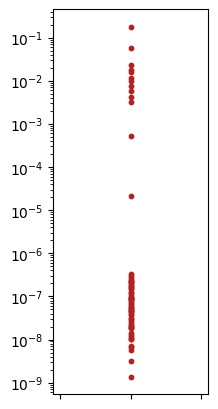

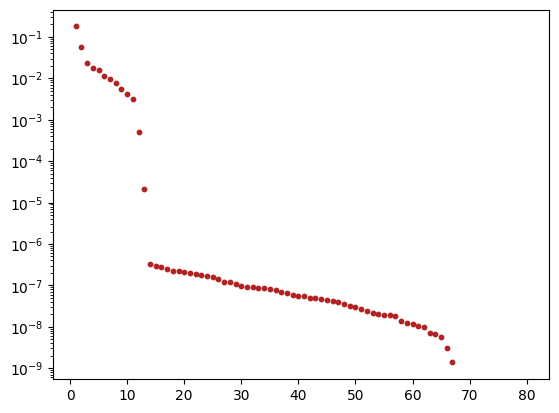

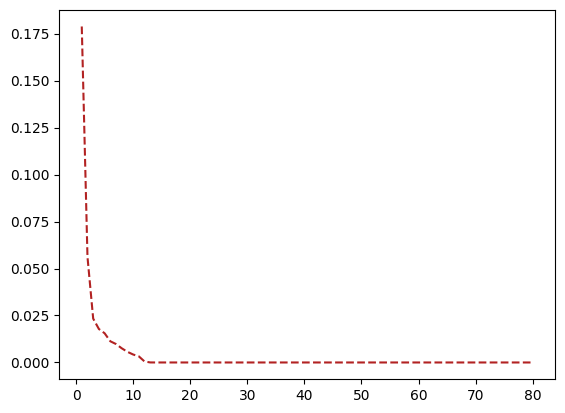

In [15]:
eigenvalues, eigenvectors = np.linalg.eigh(Q)
print("Eigenvalues:\n", np.flip(eigenvalues))

x = np.ones(N)
plt.figure(figsize=(2, 5))
plt.gca().set_xticklabels([])
plt.scatter(x, eigenvalues, color = 'firebrick', s = 10)
plt.yscale('log')
plt.show()

x = np.linspace(1,N,N)
plt.yscale('log')
plt.scatter(x, np.flip(eigenvalues), color = 'firebrick', s = 10)
plt.show()

x = np.linspace(1,N,N)
plt.plot(x, np.flip(eigenvalues), color = 'firebrick', linestyle = '--')

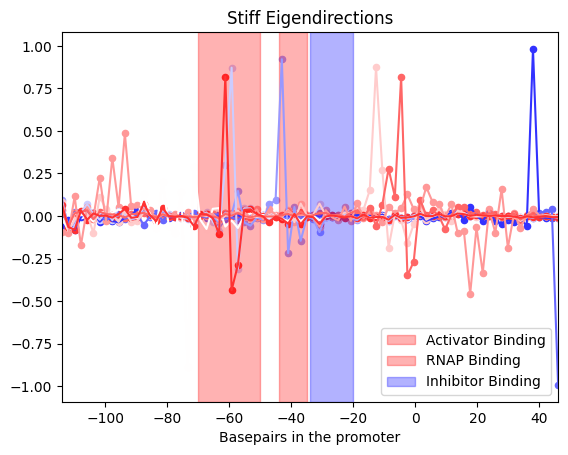

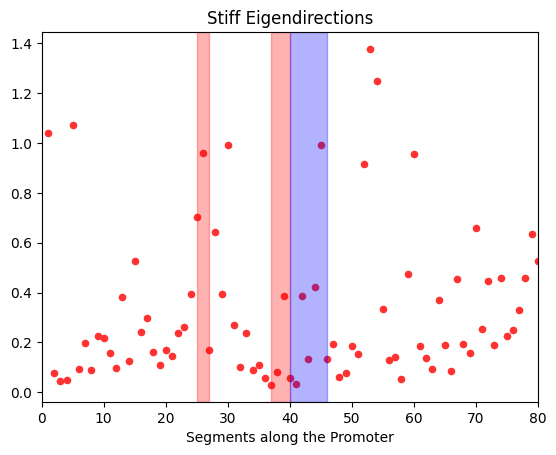

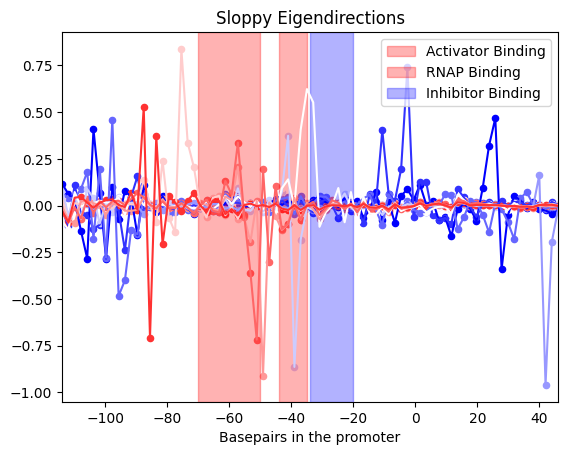

In [60]:


x = np.linspace(-114, 46, 80)

cmap = plt.get_cmap('bwr')
colors = [cmap(i / 10) for i in range(11)]
    
plt.xlim(-114, 46)
for i in range(71,80):
    plt.scatter(x, np.flip(eigenvectors[i]), color=colors[i-70], s = 20)
    plt.plot(x, np.flip(eigenvectors[i]), color = colors[i-70])
    plt.title('Stiff Eigendirections')
    plt.xlabel('Basepairs in the promoter')
plt.axvspan(-70,-50, color = 'red', alpha=0.3, label = 'Activator Binding')
plt.axvspan(-44,-35, color = 'red', alpha=0.3, label = 'RNAP Binding')
plt.axvspan(-34,-20, color = 'blue', alpha=0.3, label = 'Inhibitor Binding')
plt.legend()
plt.show()

x_pairs = np.linspace(1,80,80)
stiff = np.zeros(80)
for i in range(71,80):
    stiff += np.abs(eigenvectors[i])
plt.scatter(x_pairs, stiff, color=colors[i-70], s = 20)
plt.title('Stiff Eigendirections')
plt.xlabel('Segments along the Promoter')
plt.axvspan(25,27, color = 'red', alpha=0.3, label = 'Activator Binding')
plt.axvspan(37,40, color = 'red', alpha=0.3, label = 'RNAP Binding')
plt.axvspan(40,46, color = 'blue', alpha=0.3, label = 'Inhibitor Binding')
plt.xlim(0,80)
plt.show()

plt.xlim(-114, 46)
for i in range(10,20):
    plt.scatter(x, np.flip(eigenvectors[i]), color = colors[i - 10], s = 20)
    plt.plot(x, np.flip(eigenvectors[i]), color = colors[i - 10])
    plt.title('Sloppy Eigendirections')
    plt.xlabel('Basepairs in the promoter')
plt.axvspan(-70,-50, color = 'red', alpha=0.3, label = 'Activator Binding')
plt.axvspan(-44,-35, color = 'red', alpha=0.3, label = 'RNAP Binding')
plt.axvspan(-34,-20, color = 'blue', alpha=0.3, label = 'Inhibitor Binding')
plt.legend()
plt.show()
    

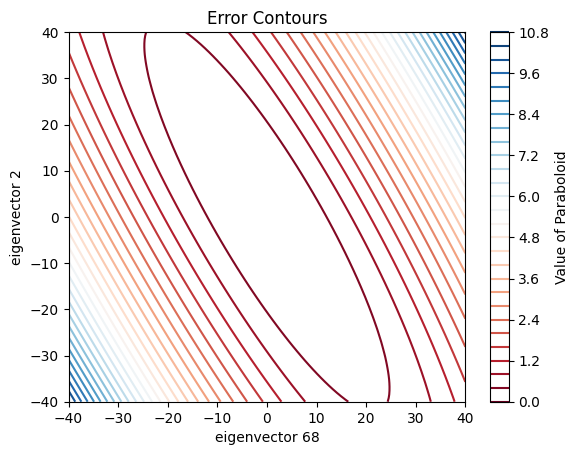

In [58]:

eigenvalues, eigenvectors = np.linalg.eigh(Q)


x_vals = np.linspace(-40, 40, 100)
y_vals = np.linspace(-40, 40, 100)
X, Y = np.meshgrid(x_vals, y_vals)

k = 68
j = 2

x = eigenvectors[k]
y = eigenvectors[j]



for i in range(80):
    Z += eigenvalues[i] * (X * x[i] + Y * y[i])**2

plt.contour(X, Y, Z, levels=30, cmap = 'RdBu')
plt.xlabel(f'eigenvector {k}')
plt.ylabel(f'eigenvector {j}')
plt.title('Error Contours')
plt.colorbar(label='Value of Paraboloid')
plt.show()